Phase 1 — Experiment 5 LABEL ORDER _order_clean_delta_MV

pred_len: 96 and 192 only All 3 alphas: 0.5, 1.0, 2.0 1 seed only (say 2021)

That's 2 × 3 × 1 = 6 runs

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1'
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1


In [3]:
!ls -la experiments/exp5b_label_order_clean_delta_MV/e5b_lab_ord_clean_delta_mv_ph1.sh

-rw------- 1 root root 8993 Apr  5 19:08 experiments/exp5b_label_order_clean_delta_MV/e5b_lab_ord_clean_delta_mv_ph1.sh


In [4]:
import os

# Set your Informer data directory
informer_path = f'{project_path}/Informer2020-original'
data_dir = f'{informer_path}/data/ETT'
os.makedirs(data_dir, exist_ok=True)

# File path
data_file = f'{data_dir}/ETTh1.csv'

# Download ETTh1 dataset
if not os.path.exists(data_file):
    print("Downloading ETTh1.csv...")
    os.system(
        f'wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" '
        f'-O "{data_file}"'
    )

# Verify
if os.path.exists(data_file):
    print(f"✅ Download successful: {data_file}")
else:
    print("❌ Download failed.")

✅ Download successful: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/data/ETT/ETTh1.csv


In [5]:
# Fix np.Inf -> np.inf in tools.py (removed in NumPy 2.0)
tools_path = f'{project_path}/Informer2020-original/utils/tools.py'

with open(tools_path, 'r') as f:
    content = f.read()

content_fixed = content.replace('np.Inf', 'np.inf')

with open(tools_path, 'w') as f:
    f.write(content_fixed)

print("✅ Fixed np.Inf -> np.inf in utils/tools.py")

✅ Fixed np.Inf -> np.inf in utils/tools.py


In [9]:
!rm "/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/logs/exp5b_label_order_clean_delta_phase1/exp5b_ph1_ETTh1_lod_clean_pred96_seed2021.log"
!rm "/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/logs/exp5b_label_order_clean_delta_phase1/exp5b_ph1_ETTh1_lod_clean_pred192_seed2021.log"

In [10]:
!bash experiments/exp5b_label_order_clean_delta_MV/e5b_lab_ord_clean_delta_mv_ph1.sh

 Experiment 5b — Phase 1: Label + Order Clean Delta
 Date: Sun Apr  5 07:19:33 PM UTC 2026
------------------------------------------------------------
 Architecture:
   Q, K  ← combined_emb  (value + temporal + legendre)
   V     ← delta_x       (x_i - x_{i-1}, value_emb ONLY)
------------------------------------------------------------
 What is fixed:   single config, no alpha sweep
 What is swept:   pred_len in {96, 192}
 Seed:            2021 (Phase 1 only)
 Total runs:      2
------------------------------------------------------------
 Reference results (Exp1-Pre, alpha=1.0, seed=2021):
   pred_len=96  → MSE ~0.725, MAE ~0.652  [CHECK YOUR LOGS]
   pred_len=192 → MSE ~0.725, MAE ~0.652  [CHECK YOUR LOGS]
 Reference results (Exp5, seed=2021):
   pred_len=96  → MSE ~0.719, MAE ~0.635  [CHECK YOUR LOGS]
   pred_len=192 → MSE ~0.719, MAE ~0.635  [CHECK YOUR LOGS]

Copying model files to /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/models/ ...
File copy comp

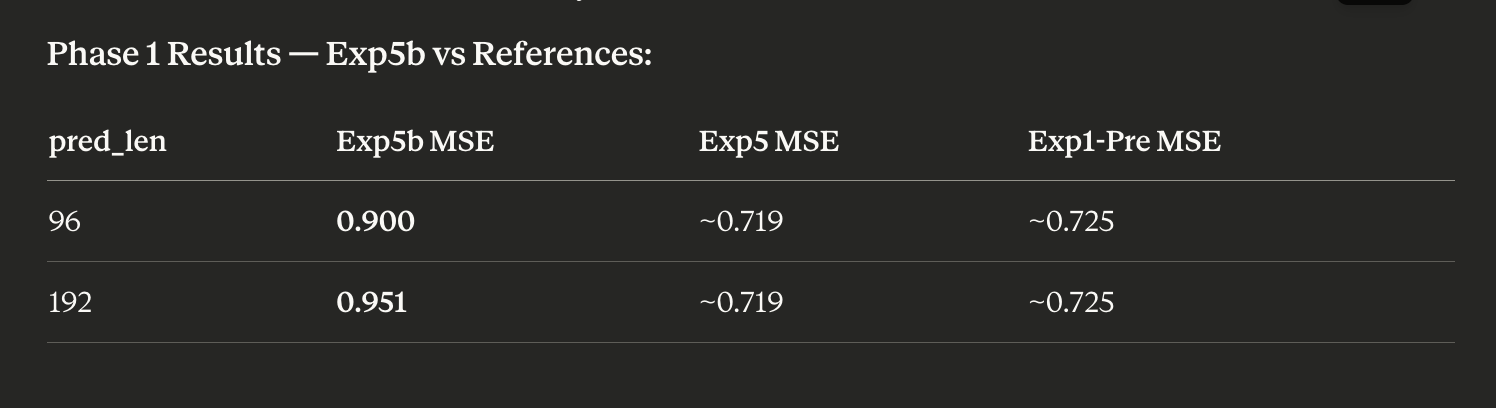

## Verdict: Do NOT proceed to Phase 2.

Exp5b is dramatically worse than everything — not marginally, not mixed. It's ~25% higher MSE than Exp5 at pred_96 and ~32% higher at pred_192. It loses to Exp1-Pre by the same margin. This isn't noise or seed variance — a 0.18+ MSE gap at a single seed is a clear signal.

## What this means scientifically:

The hypothesis that "separating positional Label and semantic Order into orthogonal spaces would reduce redundancy" did not play out. The clean delta x_i - x_{i-1} in value embedding space is actually a weaker ordering signal than the positional delta from Legendre space used in Exp5. Using raw value differences for V means the model aggregates semantic differences rather than the richer positional structure — and that hurts badly.

Also notice the training behaviour: validation loss never improved after epoch 1 in both runs, and early stopping triggered at epoch 4. The model isn't learning well at all — this isn't a generalisation problem, it's an optimisation problem with the architecture itself.

## What to document and move on with:

- Exp5b: negative result, MSE 0.900 / 0.951 at pred 96/192  
- Clean semantic delta for V is worse than positional delta (Exp5) and worse than distance decay (Exp1-Pre)  
- The paper's claim that L+O fails to match standard PE appears to hold even with the cleaner signal separation  
- Best result remains Exp1-Pre, alpha=1.0